# Analysis of data from Probe C at Moab UMTRA Project field site
Esteban Bowles-Martinez and Fred Day-Lewis, last modified 01/09/2026

Using code adapted from: McAliley, W.A., Rey, D.M., and Day-Lewis, F.D., in USGS review, Data release for tempest1d: Recursive Estimation of Vertical Groundwater/Surface-Water Exchange using Heat Tracing, U.S. Geological Survey Data Release, https://doi.org/10.5066/P99DBTKT.

Using `tempest1d.py` to predict streambed discharge from temperature measurements from the Hanford site in WA.

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tempest1d import EKF, simulate, ModelProperties, run_EKF, run_RTS
import pandas as pd
import math

# Load Moab data

We use data from a vertical temperature installation at a site on the Colorado River near Moab, Utah, adjacent to the UMTRA site. This is supplemented with meteorological data, river level, and well data. The nearest stream gage is at Potash, 25 km downstream and 19.03 vertical feet lower. We can correct for the difference in river level, but not for the difference in flow timing.

In [3]:
moab = pd.read_csv("Moab_stake_C_filtered_river.csv")
moab["datetime"] = pd.to_datetime(moab["datetime"], format="%m/%d/%Y %H:%M")

# Calibration values
calibrations = {'C_02.5cm': 0.264, 'C_10cm': 0.251, 'C_20cm': 0.302, 'C_35cm': 0.156}

# Correct river height to sea level
# Potash stream gage reference altitude from metadata of https://waterdata.usgs.gov/monitoring-location/09185600
# Keep in mind - this is at Potash, ~25 km downstream.
# River level beside UMTRA is higher by whatever elevation drop is between the two, ~25 ft on Google Earth.
river_ref = 3926.29
# Found lidar data from state of utah on Opentopography.org.
river_at_potash = 1199.29/.3048 # Edge of river at Potash: 1199.29 m = 3934.68 ft
river_at_umtra = 1205.09/.3048 # Edge at Moab Wash confluence at UMTRA
potash_diff = river_at_umtra - river_at_potash # 19.03 ft drop
moab["river_abs"] = moab["river_ft"] + river_ref + potash_diff

# Daily meteorological data
met = pd.read_csv("weather_and_river_discharge.csv",skipinitialspace=True)

# Well levels from wells 0405 and 780
wells = pd.read_csv("well_levels.csv")

# Subtract calibration values from each corresponding column
for column, cal_value in calibrations.items():
    moab[column] = moab[column] - cal_value


display(moab.head())
display(met.head())
display(wells.head())

FileNotFoundError: [Errno 2] No such file or directory: 'weather_and_river_discharge.csv'

## Plot the temperature data
Confirm it makes sense. Deeper sensors should be smoother and phase-shifted.
Also including the river level.

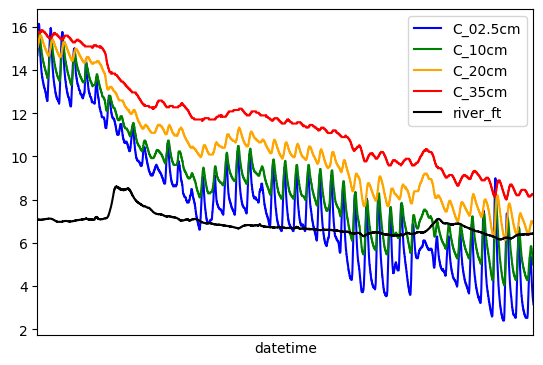

In [4]:
ax = moab.plot('datetime', ['C_02.5cm', 'C_10cm', 'C_20cm', 'C_35cm', 'river_ft'], color=['blue', 'green', 'orange', 'red', 'black'])

# Set major and minor ticks on the x-axis
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# Set major tick formatter
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.gcf().autofmt_xdate()  # Auto formats the x-axis labels to fit them in the plot

plt.show()

If there are gaps in the data, the Kalman filter can accomodate them as long as we remove the NaN values in the data.

## Add the daily met data to the temperature plots.

In [5]:
# Ensure datetime conversion for both dataframes
moab['datetime'] = pd.to_datetime(moab['datetime'])
met['Date'] = pd.to_datetime(met['Date'])

# Create the main figure and primary axis
fig, ax = plt.subplots()

# Plot the moab data using ax.plot() for the temperature probe and river level data
cols = ['C_02.5cm', 'C_10cm', 'C_20cm', 'C_35cm', 'river_ft']
colors = ['blue', 'green', 'orange', 'red', 'black']
for col, col_color in zip(cols, colors):
    ax.plot(moab['datetime'], moab[col], label=col, color=col_color)
ax.set_ylabel("Temperature (°C)")
   
# Calculate the asymmetric errors for the met air temperature data in Celsius
lower_errors = met['temp_avg_C'] - met['temp_low_C']
upper_errors = met['temp_high_C'] - met['temp_avg_C']
asymmetric_error = [lower_errors, upper_errors]

# Overlay the met air temperature errorbars on the primary axis
ax.errorbar(met['Date'], met['temp_avg_C'], yerr=asymmetric_error,
            fmt='o', capsize=0, elinewidth=.5, markersize=3,
            color='purple', label='Air Temp')

# Format the x-axis to display dates nicely
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))  # Major ticks every 7 days
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=24)) # Minor ticks every 24 hours
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()

# Create a secondary y-axis for precipitation (rain_mm)
ax2 = ax.twinx()

# Plot rain_mm as a bar plot. Since the met data is once-a-day, a width of 0.8 means the bar spans 0.8 days.
ax2.bar(met['Date'], met['rain_mm'], width=0.5, color='cyan', alpha=0.5, label='Rain (mm)')

# Set the secondary y-axis limit so that bars occupy the bottom third of the plot:
ax2.set_ylim(0, 2 * met['rain_mm'].max())

# Label the secondary y-axis and set tick color to match the bars
ax2.set_ylabel('Rain (mm)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()


NameError: name 'met' is not defined

# Predict discharge using the extended Kalman filter

In [6]:
## time between measurements

spd = 60.*60.*24. # seconds per day
datetime_all = moab['datetime']
times_all = (datetime_all - datetime_all[0]).dt.total_seconds().to_numpy()
# days = times/60/60/24
# nt = len(times)
# dt = np.diff(times)

## Physical constants
Kt = 1.82691 # thermal conductivity, W/(m deg C)
Cw = 4.182e6 # J/(m^3 deg C)
Cs = 3.03605e6 # J/(m^3 deg C)

## Set up the model
measure_points = np.array([0.20]) # depths of inner sensors
n_measurements = len(measure_points)

mp = ModelProperties(top_depth=0.10, bottom_depth=0.35, n_depths=31, 
                     Kt=Kt, Cw=Cw, Cs=Cs) # use depths of top and bottom sensors as the input arguments

In [7]:
## Boundary temperatures

# indices of top and bottom model cells
i_kalman_top = np.where(mp.depths==mp.top_depth)[0][0]
i_kalman_bottom = np.where(mp.depths==mp.bottom_depth)[0][0]

# temperatures at those boundary model indices, taken directly from sensor data
T_kalman_top_all = moab['C_10cm'].to_numpy()  # modify if not using top sensor (it might not be in saturated soil)
T_kalman_bottom_all = moab['C_35cm'].to_numpy()


In [8]:
## Measurements, including gaps
measurements_all = moab.loc[:,['C_20cm']].to_numpy().T

## Remove nans
any_nans = moab.isna().any(axis=1).to_numpy() # identify sample times with a nan on any sensor
all_valid = ~any_nans
# keep only nan-less sample times, for all the arrays
measurements = measurements_all[:, all_valid]
T_kalman_top = T_kalman_top_all[all_valid]
T_kalman_bottom = T_kalman_bottom_all[all_valid]
datetime = datetime_all[all_valid]
times = times_all[all_valid]

# prepare for working in days rather than seconds
days = times/spd
dt = np.diff(times)
dt_days = np.diff(days)
nt = len(times)

# print to confirm samples are the expected shape of one row per inner sensor and one column per sample
measurements_all.shape

(1, 4071)

In [9]:
# interpolate initial temperatures to fill in the vertical model cells from top to bottom as the initial state at time 0

T_initial = np.linspace(T_kalman_top[0], T_kalman_bottom[0], mp.n_depths)
q_initial = 0 # set the initial discharge to 0

## Create an `EKF` object

In [10]:
def new_EKF():
    '''
    Instantiate a new EKF object
    '''
    # initial state: internal temperatures concatenated with discharge
    x0 = np.r_[T_initial[(i_kalman_top + 1):i_kalman_bottom], q_initial]
    # initial boundary temperatures
    Tbc0 = np.r_[T_kalman_top[0], T_kalman_bottom[0]]
    # number of state variables
    nx = len(x0)
    # create the ekf object
    ekf = EKF(measure_points, dt[0], mp, interp=True, Tbc0=Tbc0)
    # initialize state
    ekf.x = x0
    
    ## Choose covariance matrices
    # initial state covariance
    # temperatures
    ekf.P = np.eye(nx)*5**2 # (deg C)^2
    # discharge
    ekf.P[-1, -1] = (1/spd)**2 # (m/s)^2

    # process covariance
    # temperatures
    ekf.Q = np.eye(nx)*1e-2**2 # (deg C)^2
    # discharge
    ekf.Q[-1, -1] = 3e-8**2 # (m/s)^2
    
    # standard deviation of temperature measurements
    #T_noise_std = 0.0288 # deg C
    T_noise_std = 0.0625/np.sqrt(3) # sensor resolution is .0625 deg C
    #T_noise_std = 0.3
    #T_noise_std = .0625
    # control covariance
    ekf.control_covariance = np.eye(2)*T_noise_std**2

    # measurement covariance
    ekf.R = np.eye(n_measurements)*T_noise_std**2

    return ekf

## Choose covariance matrices

### Discharge process variance sweep

In order to determine the optimal discharge process variance, we apply the EKF using several different values. This process takes several minutes. We could speed it up by applying the analysis to a subset of the data, but for the sake of a thorough investigation and for simplicity, we apply the EKF to the full dataset each time.

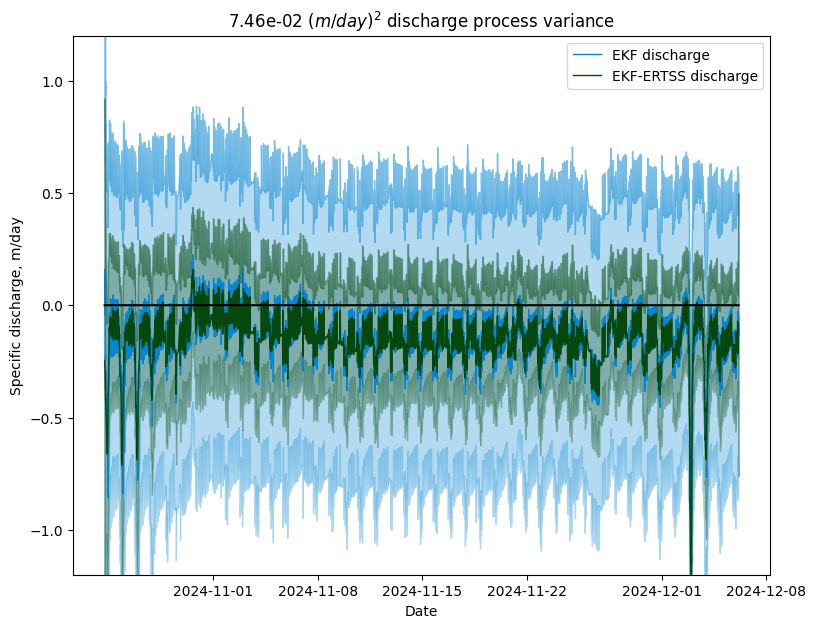

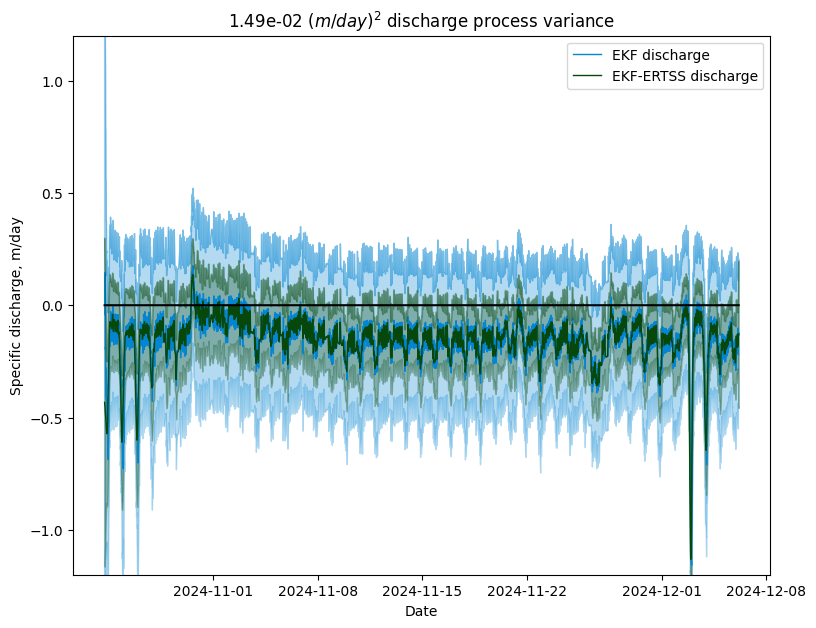

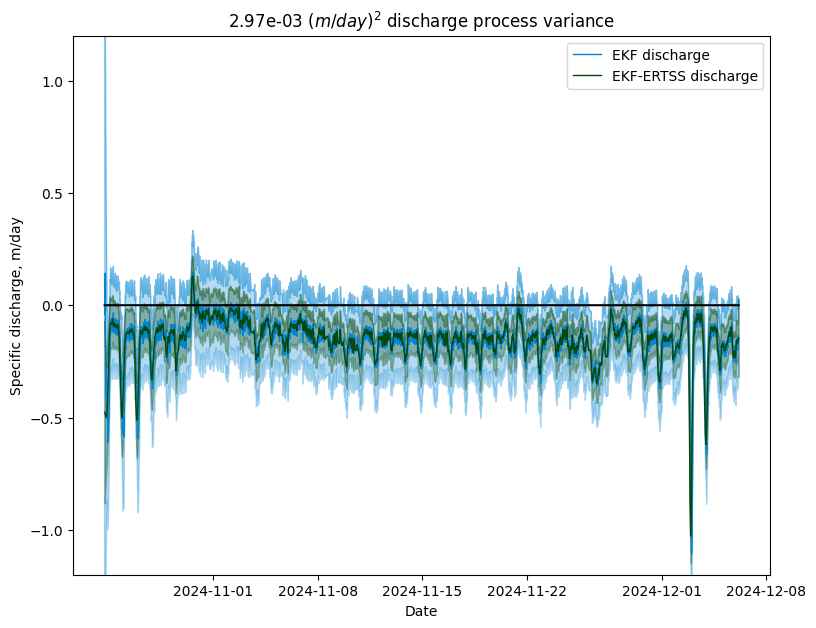

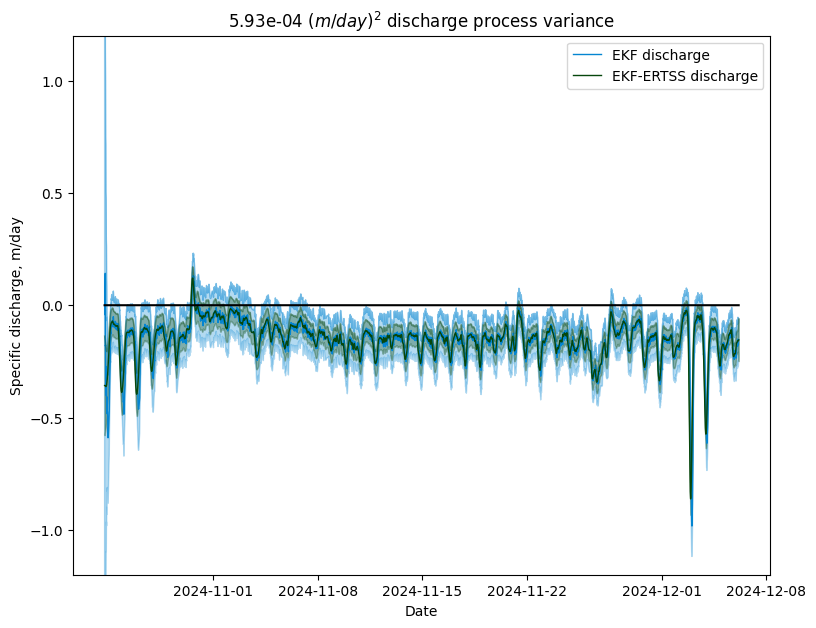

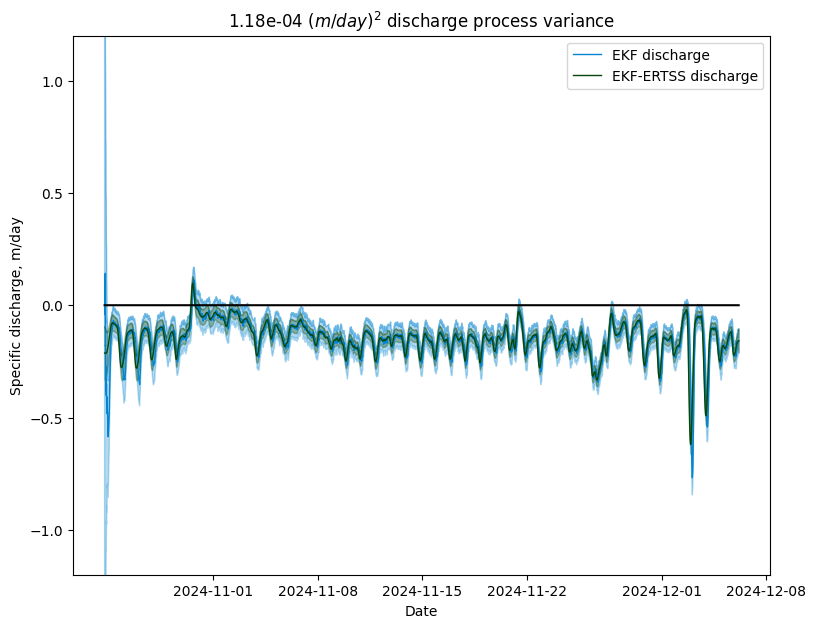

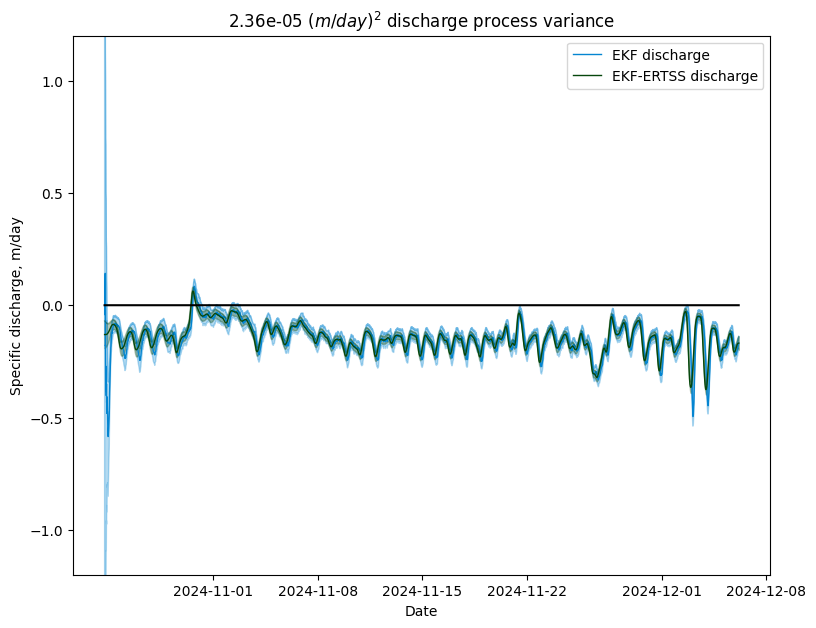

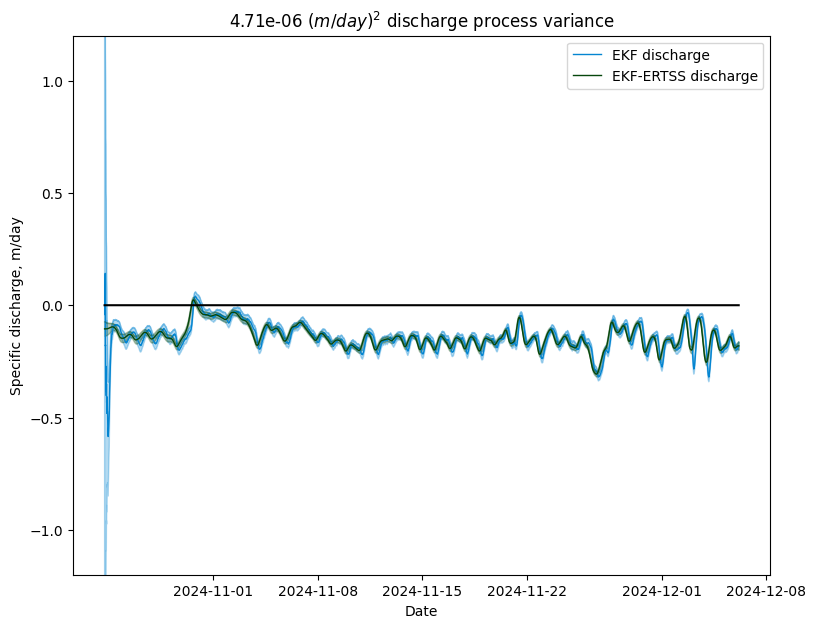

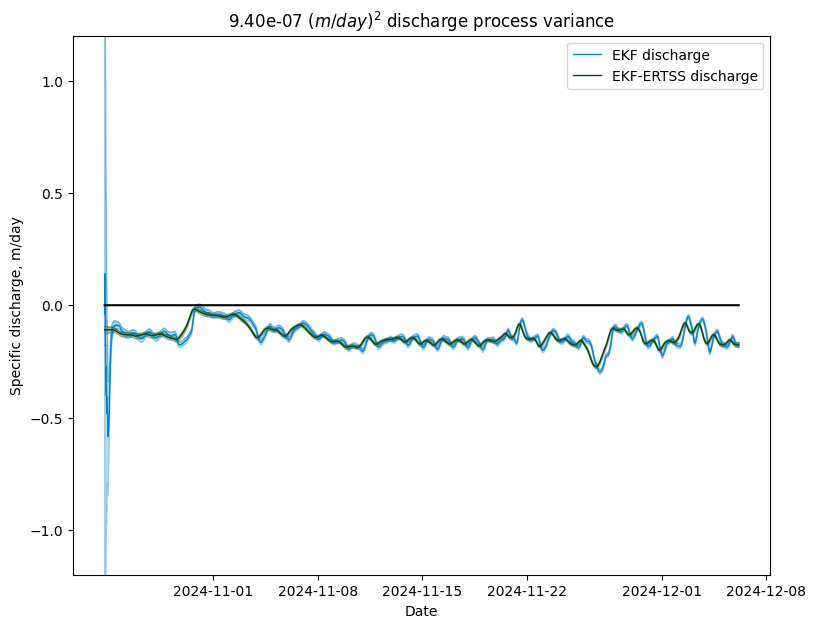

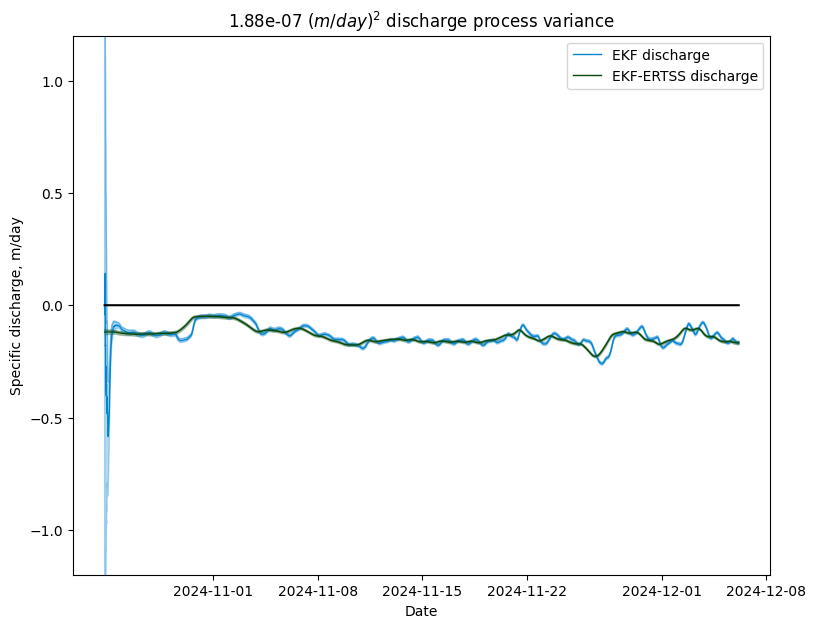

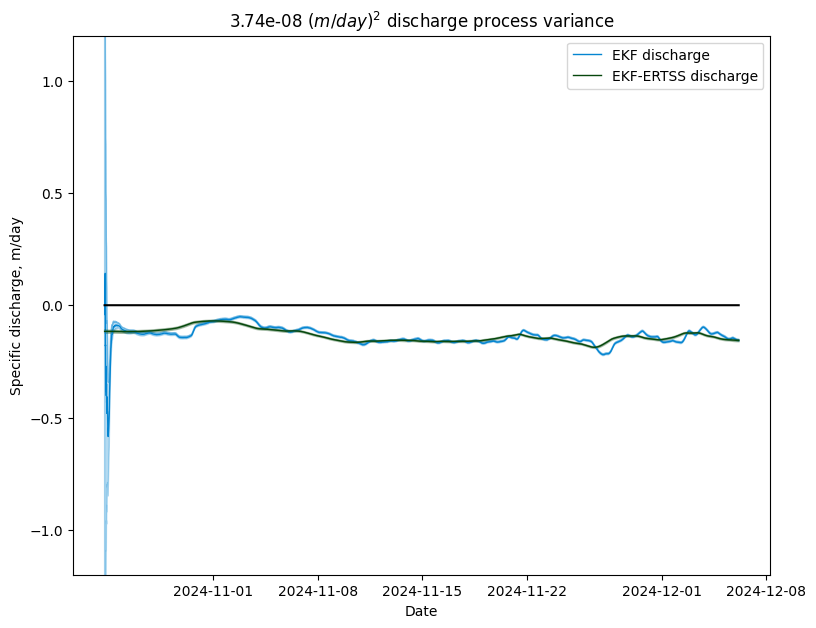

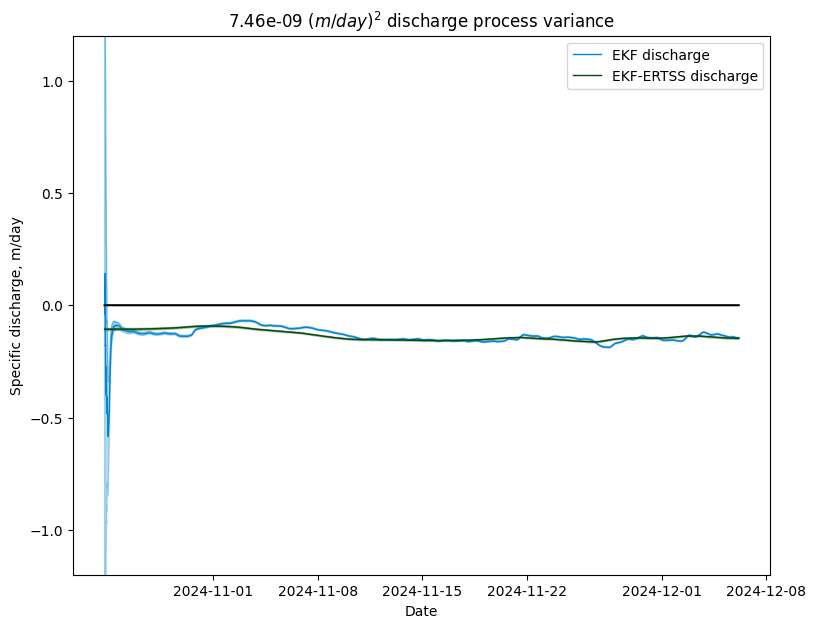

In [11]:
# Loop over discharge process variance values
vqs = np.logspace(-11, -18, 11)
phids_ekf = []
phims_ekf = []
phids_rts = []
phims_rts = []
for vq in vqs:
    ekf = new_EKF()
    ekf.Q[-1, -1] = vq # (m/s)^2
    Qc = ekf.Q/dt[0]
    x_ekf, y_ekf, P_ekf = run_EKF(ekf, measurements, T_kalman_top, T_kalman_bottom,
                                  dt=dt, Qc=Qc, return_full_P=True)
    P_q_ekf = P_ekf[:, -1, -1]
    
    # get predicted discharge, convert to m/day
    q_ekf = x_ekf[:,mp.nz]*spd # m/day
    # get standard deviation of discharge as estimated by the filter
    q_std = np.sqrt(P_q_ekf)*spd # m/day
    # convert to a 95% confidence interval
    q_ci = q_std*1.96 # m/day    
    
    # Compute data misfit
    phid = np.sum(np.dot(y_ekf, np.linalg.inv(ekf.R)) * y_ekf)
    phids_ekf.append(phid)
    # Compute model flatness term
    phim = np.sum((np.diff(q_ekf)/dt_days)**2)
    phims_ekf.append(phim)
    
    x_rts, y_rts, P_q_rts = run_RTS(ekf, x_ekf, P_ekf, measurements, T_kalman_top, T_kalman_bottom,
                                    dt=dt, Qc=Qc, return_full_P=False)
    
    # get predicted discharge, convert to m/day
    q_rts = x_rts[:,mp.nz]*spd # m/day
    # get standard deviation of discharge as estimated by the filter
    q_rts_std = np.sqrt(P_q_rts)*spd # m/day
    # convert to a 95% confidence interval
    q_rts_ci = q_rts_std*1.96
    
    # Compute data misfit
    phid = np.sum(np.dot(y_rts, np.linalg.inv(ekf.R)) * y_rts)
    phids_rts.append(phid)
    # Compute model flatness term
    phim = np.sum((np.diff(q_rts)/dt_days)**2)
    phims_rts.append(phim)

    fig, ax = plt.subplots(figsize=(9,7))
    p_ekf = ax.plot(datetime, q_ekf, linewidth=1, color='xkcd:cerulean')
    ax.plot(datetime, q_ekf + q_ci, linewidth=1, color='xkcd:cerulean', alpha=0.3)
    p_rts = ax.plot(datetime, q_rts, linewidth=1, color='xkcd:forest green')
    ax.plot(datetime, q_rts + q_rts_ci, linewidth=1, color='xkcd:forest green', alpha=0.3)
    #p_vflux = ax.plot(vflux['time'], vflux['vertical_flux_m_d'], linewidth=1, color='xkcd:orange')
    #ax.legend(p_ekf + p_rts + p_vflux,
    #          ['EKF discharge', 'EKF-ERTSS discharge', 'VFlux discharge'])
    ax.legend(p_ekf + p_rts,
              ['EKF discharge', 'EKF-ERTSS discharge'])
    
    ax.fill_between(datetime, q_ekf - q_ci, q_ekf + q_ci, color='xkcd:cerulean', alpha=0.3)
    ax.fill_between(datetime, q_rts - q_rts_ci, q_rts + q_rts_ci, color='xkcd:forest green', alpha=0.3)
    ax.plot(datetime, [0]*len(datetime), color='k')
    plt.title('{0:.2e} $(m/day)^2$ discharge process variance'.format(vq*spd*spd))
    plt.ylim(-1.2, 1.2)
    plt.xlabel('Date')
    plt.ylabel('Specific discharge, m/day')
    plt.show()

These plots show how the value of the discharge process variance affects the EKF discharge prediction. A smaller variance results in a predicted discharge that varies more smoothly with time. It also results in smaller predicted discharge variance, observable in these plots as a more narrow confidence interval.

### Discrepancy principle

Following the discrepancy principle, the optimal choice of discharge process variance is the one that yields the data misfit closest to the expected data misfit. For Gaussian measurement noise, the expected value of the distribution is the number of data. Therefore, if we divide the data misfit by the number of data, then a result of one will correspond to the optimal discharge process variance.

In [12]:
#import matplotlib.dates as mdates - import is now at top
plt.rc('font', size=22)
plt.rc('figure', figsize=(9,7))
spd = 60.*60.*24.

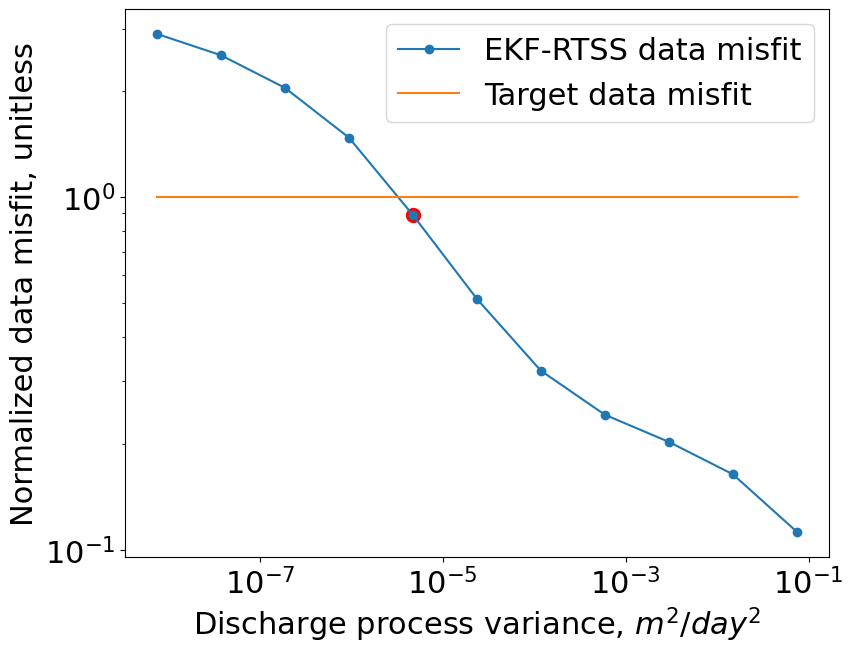

In [13]:
n_data = len(y_ekf.flatten())
i_opt = 6
plt.loglog(vqs*spd*spd, np.array(phids_rts)/n_data, '-o')
plt.loglog(vqs*spd*spd, [1]*len(vqs))
plt.scatter(vqs[i_opt]*spd*spd, phids_rts[i_opt]/n_data, s=100, c='red', marker='o') # marker for the optimal value
plt.xlabel('Discharge process variance, $m^2/day^2$')
plt.ylabel('Normalized data misfit, unitless')
plt.legend(['EKF-RTSS data misfit', 'Target data misfit'])
plt.tight_layout()
plt.show()

## Apply filter using optimal choice for process variance.

For the sake of saving RAM, we didn't save the results from the sweep. So, now let's use the optimal discharge process variance value to run the filter once more. We'll use the optimal value from the discrepancy principle.

In [14]:
# EKF filter
ekf = new_EKF()
#ekf.Q[-1, -1] = vqs[6] # (m/s)^2
#vqsuse=vqs[3] # choose the index of the optimal variance identified previously or pick your own
vqsuse=vqs[i_opt]
ekf.Q[-1, -1] = vqsuse # (m/s)^2
Qc = ekf.Q/dt[0]
x_ekf, y_ekf, P_ekf = run_EKF(ekf, measurements, T_kalman_top, T_kalman_bottom,
                              dt=dt, Qc=Qc, return_full_P=True)
P_q_ekf = P_ekf[:, -1, -1]

# get predicted discharge, convert to m/day
q_ekf = x_ekf[:,mp.nz]*spd # m/day
# get standard deviation of discharge as estimated by the filter
q_std = np.sqrt(P_q_ekf)*spd # m/day
# convert to a 95% confidence interval
q_ci = q_std*1.96 # m/day    

x_rts, y_rts, P_q_rts = run_RTS(ekf, x_ekf, P_ekf, measurements, T_kalman_top, T_kalman_bottom,
                                dt=dt, Qc=Qc, return_full_P=False)

# get predicted discharge, convert to m/day
q_rts = x_rts[:,mp.nz]*spd # m/day
# get standard deviation of discharge as estimated by the filter
q_rts_std = np.sqrt(P_q_rts)*spd # m/day
# convert to a 95% confidence interval
q_rts_ci = q_rts_std*1.96

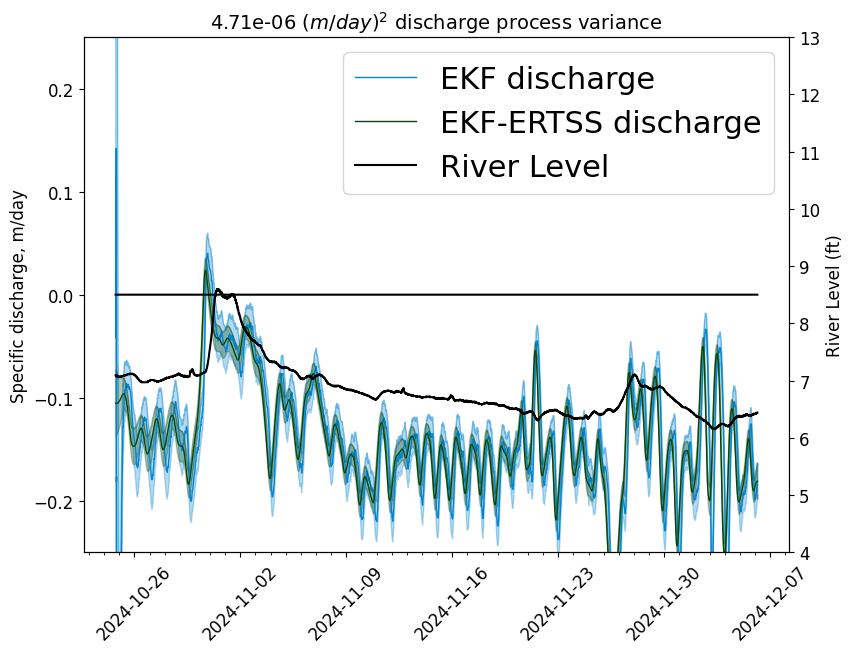

,q,c
datetime,,
2024-10-24 18:14:00,-0.105337,0.031480
2024-10-24 18:29:00,-0.105338,0.031192
2024-10-24 18:44:00,-0.105337,0.030901
2024-10-24 18:59:00,-0.105340,0.030606
2024-10-24 19:14:00,-0.105348,0.030309


In [15]:
fig, ax = plt.subplots(figsize=(9,7))

# Plotting data for primary y-axis
p_ekf = ax.plot(datetime, q_ekf, linewidth=1, color='xkcd:cerulean')
ax.plot(datetime, q_ekf + q_ci, linewidth=1, color='xkcd:cerulean', alpha=0.3)
p_rts = ax.plot(datetime, q_rts, linewidth=1, color='xkcd:forest green')
ax.plot(datetime, q_rts + q_rts_ci, linewidth=1, color='xkcd:forest green', alpha=0.3)
ax.fill_between(datetime, q_ekf - q_ci, q_ekf + q_ci, color='xkcd:cerulean', alpha=0.3)
ax.fill_between(datetime, q_rts - q_rts_ci, q_rts + q_rts_ci, color='xkcd:forest green', alpha=0.3)
ax.plot(datetime, [0]*len(datetime), color='k')

# Creating a secondary y-axis
ax2 = ax.twinx()
ax2.plot(moab['datetime'], moab['river_ft'], color='black', label='River Level (ft)')

# Setting x-axis major and minor ticks
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))  # Major ticks every 7 days
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=24))  # Minor ticks every 24 hours
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format for the major ticks

# Legend
ax.legend(p_ekf + p_rts + [ax2.get_lines()[-1]],
          ['EKF discharge', 'EKF-ERTSS discharge', 'River Level'])

# Styling adjustments
label_font_size = 12
ax.tick_params(axis='x', rotation=45, labelsize=label_font_size)  # Adjust x-axis labels
ax.tick_params(axis='y', labelsize=label_font_size)  # Adjust y-axis label font size for primary y-axis
ax.set_ylim(-.25, .25)
ax2.tick_params(axis='y', labelsize=label_font_size)  # Adjust y-axis label font size for secondary y-axis

plt.xlabel('Date', fontsize=label_font_size)
ax.set_ylabel('Specific discharge, m/day', fontsize=label_font_size)
ax2.set_ylabel('River Level (ft)', color='black', fontsize=label_font_size)
#plt.title('{0:.2e} $(m/day)^2$ discharge process variance'.format(vq*spd*spd), fontsize=14)
plt.title('{0:.2e} $(m/day)^2$ discharge process variance'.format(vqsuse*spd*spd), fontsize=14)
ax2.set_ylim(4, 13) # set river level axis range

plt.tight_layout()
plt.show()

# convert array into dataframe
A=np.array([q_rts.T, q_rts_ci.T]).T
qdf = pd.DataFrame(data=A, index=datetime, columns=list("qc"))
display(qdf.head())
    
# save the dataframe as a csv file
qdf.to_csv("Moab_C_Results.csv")

In [ ]:
vqsuse

6.309573444801943e-16

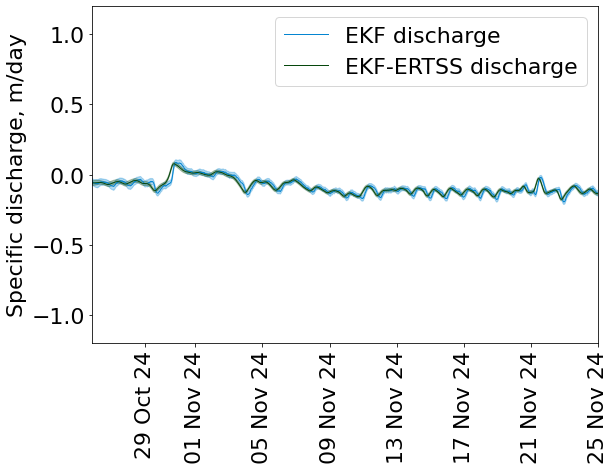

In [ ]:
# Plot detail to inspect the smoother vs. filter response.
fig, ax = plt.subplots(figsize=(9,7))
ax.plot(datetime, q_ekf, linewidth=1, color='xkcd:cerulean')
ax.plot(datetime, q_rts, linewidth=1, color='xkcd:forest green')
#vflux.plot('time', 'vertical_flux_m_d', ax=ax, color='xkcd:orange')
#ax.legend(['EKF discharge', 'EKF-ERTSS discharge', 'VFlux discharge'])
ax.legend(['EKF discharge', 'EKF-ERTSS discharge'])
ax.fill_between(datetime, q_ekf - q_ci, q_ekf + q_ci, color='xkcd:cerulean', alpha=0.3)
ax.fill_between(datetime, q_rts - q_rts_ci, q_rts + q_rts_ci, color='xkcd:forest green', alpha=0.3)
plt.ylim(-1.2, 1.2)
plt.ylabel('Specific discharge, m/day')
plt.xlim(datetime[100], datetime[3000])
plt.xlabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

# Big unified plot of everything

In [ ]:
# ===============================
# Create a 2-Row Subplot (Shared X-Axis)
# ===============================

## ensure they're really datetimes
#moab["datetime"] = pd.to_datetime(moab["datetime"], format="%m/%d/%Y %H:%M")
#met["Date"] = pd.to_datetime(met["Date"])
#wells['datetime_780_utc'] = pd.to_datetime(wells['datetime_780_utc'], format="%m/%d/%Y %H:%M")
#wells['datetime_0405_utc'] = pd.to_datetime(wells['datetime_0405_utc'], format="%m/%d/%Y %H:%M")

# ensure they're really datetimes in -7UTC
moab["datetime"] = pd.to_datetime(moab["datetime"], format="%m/%d/%Y %H:%M").dt.tz_localize('UTC').dt.tz_convert('US/Mountain')
met["Date"] = pd.to_datetime(met["Date"]).dt.tz_localize('UTC').dt.tz_convert('US/Mountain')
wells['datetime_780_utc'] = pd.to_datetime(wells['datetime_780_utc'], format="%m/%d/%Y %H:%M").dt.tz_localize('UTC').dt.tz_convert('US/Mountain')
wells['datetime_0405_utc'] = pd.to_datetime(wells['datetime_0405_utc'], format="%m/%d/%Y %H:%M").dt.tz_localize('UTC').dt.tz_convert('US/Mountain')

label_font_size = 12
legend_font_size = 11

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(12, 10), dpi=300)

############################
# TOP PANEL: Temperature & Precipitation
############################

# Plot temperature probe data from moab (exclude river_ft)
temp_cols = [ 'C_10cm', 'C_20cm', 'C_35cm']
temp_colors = [ 'green', 'orange', 'red']
for col, col_color in zip(temp_cols, temp_colors):
    ax_top.plot(moab['datetime'], moab[col], label=col, color=col_color)
ax_top.set_ylabel("Temperature (°C)", fontsize=label_font_size)

# Add met air temperature with asymmetric errorbars
lower_errors = met['temp_avg_C'] - met['temp_low_C']
upper_errors = met['temp_high_C'] - met['temp_avg_C']
asymmetric_error = [lower_errors, upper_errors]
ax_top.errorbar(met['Date'], met['temp_avg_C'], yerr=asymmetric_error,
                fmt='o', capsize=0, elinewidth=0.5, markersize=3,
                color='purple', label='Air Temp')
ax_top.tick_params(axis='y', labelsize=label_font_size)

# Format the x-axis dates on top panel
ax_top.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax_top.xaxis.set_minor_locator(mdates.HourLocator(interval=24))
ax_top.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax_top.xaxis.get_majorticklabels(), rotation=45)

# Add a secondary axis for precipitation on the top panel
ax_top2 = ax_top.twinx()
ax_top2.bar(met['Date'], met['rain_mm'], width=0.5, color='cyan', alpha=0.5,
            label='Rainfall (mm)')
ax_top2.set_ylim(0, 2 * met['rain_mm'].max())
ax_top2.set_ylabel("Daily rainfall (mm)", color='black', fontsize=label_font_size)
ax_top2.tick_params(axis='y', labelcolor='black', labelsize=label_font_size)
ax_top2.set_title('(a)')


# Combine legends for top panel
lines_top, labels_top = ax_top.get_legend_handles_labels()
lines_top2, labels_top2 = ax_top2.get_legend_handles_labels()
ax_top.legend(lines_top + lines_top2, labels_top + labels_top2, loc='upper right', fontsize=legend_font_size)

#############################
# BOTTOM PANEL: Discharge, River, & Well Levels
#############################

# Assume that the following variables are defined in your Notebook:
# - datetime : time vector for the discharge estimates (must be datetime-like)
# - q_ekf, q_rts : discharge estimates (arrays)
# - q_ci, q_rts_ci : confidence intervals (arrays)
# - vqsuse : a scalar value for discharge process variance
#
# (If these variables are not already defined, please ensure to create/import them.)

# Plot discharge estimates and confidence intervals on the primary y-axis
#p_ekf, = ax_bottom.plot(datetime, q_ekf, linewidth=1, color='xkcd:cerulean', label='EKF discharge')
#ax_bottom.plot(datetime, q_ekf + q_ci, linewidth=1, color='xkcd:cerulean', alpha=0.3)
p_rts, = ax_bottom.plot(datetime, q_rts, linewidth=1, color='xkcd:forest green', label='EKF-ERTSS discharge')
ax_bottom.plot(datetime, q_rts + q_rts_ci, linewidth=1, color='xkcd:forest green', alpha=0.3)
#ax_bottom.fill_between(datetime, q_ekf - q_ci, q_ekf + q_ci, color='xkcd:cerulean', alpha=0.3)
ax_bottom.fill_between(datetime, q_rts - q_rts_ci, q_rts + q_rts_ci, color='xkcd:forest green', alpha=0.3)
ax_bottom.plot(datetime, np.zeros(len(datetime)), color='k')

# Create a secondary y-axis on the bottom panel for water levels (river & wells)
ax_bottom2 = ax_bottom.twinx()

# Plot river level from moab (adjusted to absolute elevation)
p_river, = ax_bottom2.plot(moab['datetime'], moab['river_abs'], color='black', label='River Level (ft)')

# Plot well level data using the UTC datetime columns
p_well780, = ax_bottom2.plot(wells['datetime_780_utc'], wells['elevation_780'], 
                              color='red', linestyle='--', label='Well 780 Level')
p_well0405, = ax_bottom2.plot(wells['datetime_0405_utc'], wells['elevation_0405'], 
                              color='blue', linestyle='--', label='Well 0405 Level')

# Format the bottom panel x-axis (they share the x-axis with the top panel)
ax_bottom.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax_bottom.xaxis.set_minor_locator(mdates.HourLocator(interval=24))
ax_bottom.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Combine legends from both axes in the bottom panel
lines_bot1, labels_bot1 = ax_bottom.get_legend_handles_labels()
lines_bot2, labels_bot2 = ax_bottom2.get_legend_handles_labels()
ax_bottom.legend(lines_bot1 + lines_bot2, labels_bot1 + labels_bot2, loc='lower left', fontsize=legend_font_size)

# Styling and axis labels for the bottom panel
ax_bottom.tick_params(axis='x', rotation=45, labelsize=label_font_size)
ax_bottom.tick_params(axis='y', labelsize=label_font_size)
ax_bottom.set_ylim(-0.3, 0.15)
ax_bottom.set_ylabel('Specific discharge, m/day', fontsize=label_font_size)
ax_bottom.set_xlabel('Date', fontsize=label_font_size)
ax_bottom.set_title('(b)')

ax_bottom2.set_ylim(3950, 3954)
ax_bottom2.tick_params(axis='y', labelsize=label_font_size)
ax_bottom2.set_ylabel('Water Level (ft)', color='black', fontsize=label_font_size)

# -------------------------------
# Set the desired date range:
# -------------------------------
start_date = pd.to_datetime("2024-10-26 00:00:00")
end_date = pd.to_datetime("2024-12-06 00:00:00")
ax_top.set_xlim(start_date, end_date)

# Final layout adjustments
plt.tight_layout()
plt.show()


NameError: name 'met' is not defined

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\dhare\AppData\Local\Temp\ipykernel_52164\1457741283.py:12: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Residual, $\degree$C')


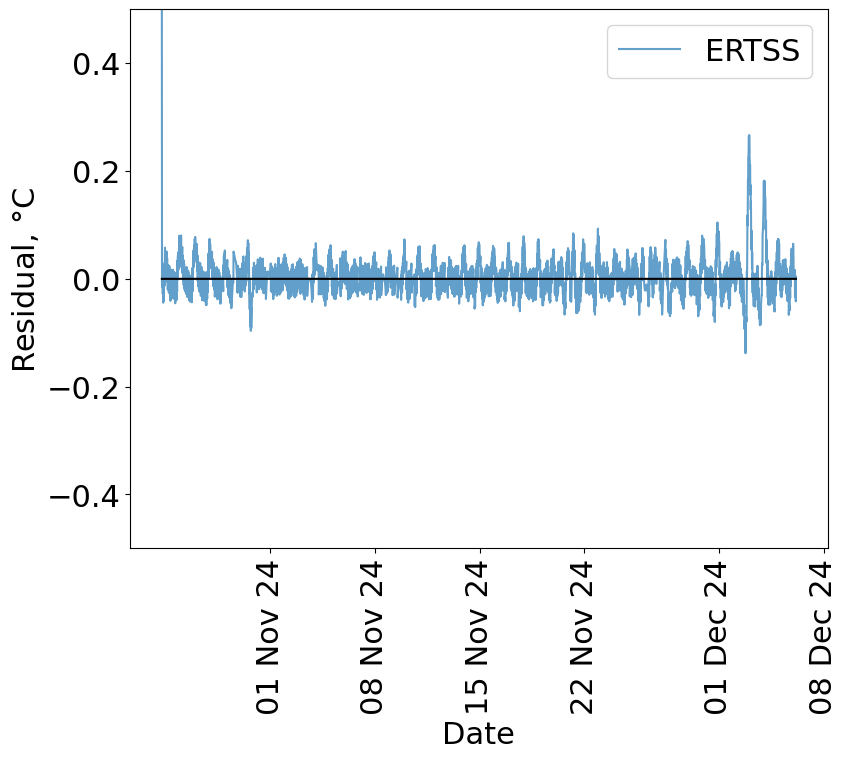

RMSE for ERTSS is 0.03402534286666649


In [17]:
# Plot measurement residuals
fig, ax = plt.subplots(figsize=(9,7))
ax.plot(datetime, np.c_[y_rts], alpha=0.7)

MSE = np.square(y_rts).mean() 
RMSE = math.sqrt(MSE)

ax.plot(datetime, [0]*len(datetime), color='k')
ax.legend(['ERTSS'])
plt.ylim(-0.5, 0.5)
plt.xlabel('Date')
plt.ylabel('Residual, $\degree$C')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
plt.xticks(rotation=90)
plt.show()
print(f"RMSE for ERTSS is {RMSE}")

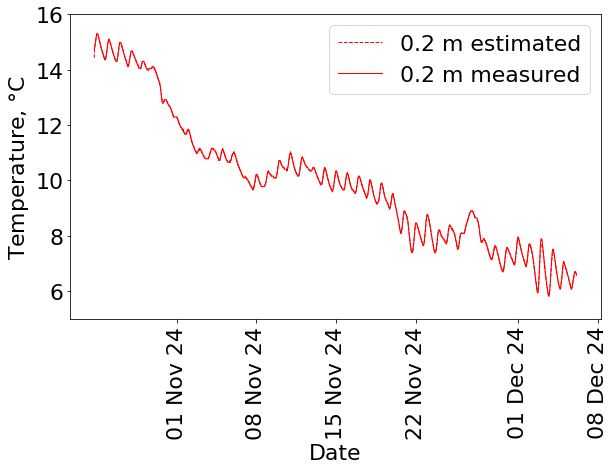

(4071, 1)

In [ ]:
# Plot measurements with estimates
z_rts = ekf.Hx(x_rts.T)
fig, ax = plt.subplots(figsize=(9,7))
ax.plot(datetime, z_rts.T[:,0], linewidth=1, ls='--',color='r')  # comment out the next two lines if only using one inner sensor
#ax.plot(datetime, z_rts.T[:,1], linewidth=1, ls='--',color='DarkOrange')  # comment out next line if using two inner sensors
#ax.plot(datetime, z_rts.T[:,2], linewidth=1, ls='--',color='b')
ax.plot(datetime, measurements.T[:,0], linewidth=1,color='r')  # comment out the next two lines if only using one inner sensor
#ax.plot(datetime, measurements.T[:,1], linewidth=1,color='DarkOrange')  # comment out next line if using two inner sensors
#ax.plot(datetime, measurements.T[:,2], linewidth=1,color='b')

#for measurement in measurements:
#ax.scatter(datetime, measurement, s=0.5, alpha=0.3)
estimated_labels = ['{} m estimated'.format(measure_point) for measure_point in measure_points]
measured_labels = ['{} m measured'.format(measure_point) for measure_point in measure_points]
plt.legend(estimated_labels + measured_labels)
plt.xlabel('Date')
plt.ylabel('Temperature, $\degree$C')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
plt.xticks(rotation=90)
#plt.xlim(datetime[18000], datetime[19000])
plt.ylim(5,16)
plt.tight_layout()
plt.show()
z_rts.T.shape